# Q2b: Use an LLM to generate predictions (LLMTIME style)

**INSTRUCTIONS TO USER:**
1. This script generates the PROMPT string representing the time series data.
2. You can use the generated string to prompt ChatGPT, Claude, or any LLM via API or Web UI to get the predictions.

In [1]:
import pandas as pd
import numpy as np

In [ ]:
import pandas as pd

# 1. Load Data
# Don't forget thousands=',' to parse the numbers correctly!
df = pd.read_csv('airline_dataset.csv', thousands=',')

# Convert YEAR and MONTH to a datetime index
month_abbr = df['MONTH'].astype(str).str[:3]
df['Date'] = pd.to_datetime(month_abbr + '-' + df['YEAR'].astype(str), format='%b-%Y')
df.set_index('Date', inplace=True)

# Always sort the index chronologically for time series
df = df.sort_index()

# Extract the training series (since 'Date' is the index, we use df.index)
train_series = df[df.index < '2023-09-01']['PASSENGERS CARRIED']

# 2. Tokenization & Formatting Strategy
# LLMTIME suggests converting numbers to string tokens and separating by commas/spaces.
# Handling Nulls: Replace NaN with 'NaN' or interpolate before prompting.

def create_llm_prompt(series, periods_to_forecast=12):
    # Convert series to list of strings
    # Ensure no NaNs or handle them
    series = series.interpolate(method='linear')
    seq_str = ", ".join([str(int(val)) for val in series.values])
    
    prompt = (
        f"You are an expert time series forecaster. "
        f"Given the following historical monthly passenger data for an airline: \n"
        f"[{seq_str}]\n\n"
        f"Please forecast the next {periods_to_forecast} values. "
        f"Only return a comma-separated list of {periods_to_forecast} integers, nothing else."
    )
    return prompt

prompt_string = create_llm_prompt(train_series, 12)
print(prompt_string)


You are an expert time series forecaster. Given the following historical monthly passenger data for an airline: 
[1408012, 1341210, 1423569, 1511094, 1685168, 1480879, 1445248, 1531406, 1378691, 1510184, 1467763, 1575872, 1426580, 1464070, 1601141, 1679963, 1908334, 1797101, 1599977, 1858664, 1907378, 1890273, 1967992, 2324221, 2276404, 2230645, 2286128, 2481285, 2769283, 2536554, 2416916, 2384943, 2430449, 2589861, 2597765, 2743325, 2725711, 2754131, 3023228, 3066556, 3336839, 3023081, 3383768, 3341081, 3295826, 3692828, 3772583, 3848322, 3809228, 3418605, 3611371, 3778780, 4190914, 3825814, 3699451, 3678245, 3664509, 4133027, 4131844, 4430070, 4556904, 4290189, 4576236, 4579916, 4852909, 4672686, 5002416, 4757378, 4920335, 5074853, 5005919, 5478523, 5321832, 4930608, 5440796, 5481088, 5979551, 5778376, 5693448, 5540693, 5559031, 5842318, 6151347, 6188457, 6119924, 5931189, 3793464, 1967859, 142254, 1046836, 1272240, 1681787, 2265539, 2926835, 3423059, 3951522, 4202712, 4238466, 41849

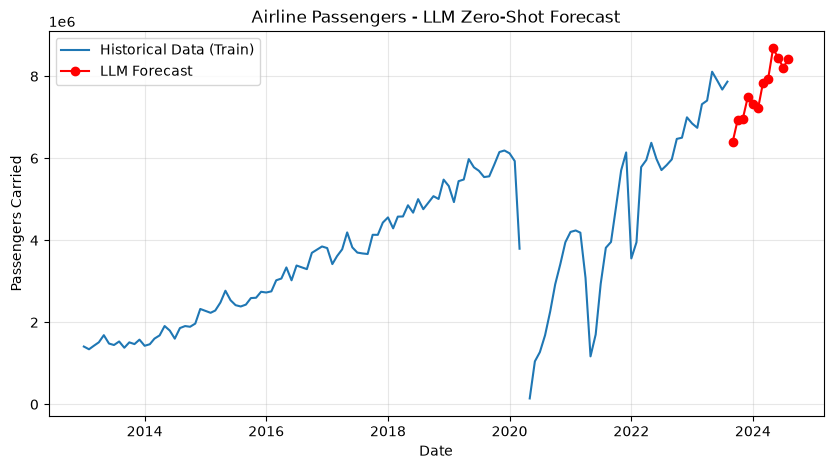

In [5]:

# 3. Evaluation
import matplotlib.pyplot as plt

# 3. Evaluation
# Paste the LLM's raw response here
llm_response = "6390520,6924442,6955966,7487295,7326701,7213884,7829498,7924891,8677300,8445827,8212132,8417967"

# Convert the string output into a list of integers
forecast_values = [int(x.strip()) for x in llm_response.split(',')]

# Generate the dates for the forecast (Next 12 months starting from Sep 2023)
# 'MS' stands for Month-Start frequency
future_dates = pd.date_range(start='2023-09-01', periods=12, freq='MS')

# Create a pandas Series so it's easy to plot with dates
llm_forecast = pd.Series(forecast_values, index=future_dates)

# Plotting the results
plt.figure(figsize=(10, 5))
plt.plot(train_series.index, train_series, label='Historical Data (Train)')
plt.plot(llm_forecast.index, llm_forecast, label='LLM Forecast', color='red', marker='o')

plt.title("Airline Passengers - LLM Zero-Shot Forecast")
plt.xlabel("Date")
plt.ylabel("Passengers Carried")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

